# NB27: Inverse PGLS — Does environmental niche predict metal-gene density?

**[EXPLORATORY / POST-HOC]**

Primary analyses (NB01–NB14) test: metal-gene density → niche breadth.  
This notebook reverses the question: do environmental niche characteristics (niche **position** and **width**) predict per-Mb metal-gene density (ko_per_mb_primary)?

**Motivation**: If genera that have evolved in consistently metal-rich, pH-restricted environments carry more metal-handling genes, this supports an evolutionary-ecological mechanism: environmental exposure drives gene accumulation. This is distinct from the forward analysis, which only establishes a statistical association.

**Niche characteristics** (computed from HMP feature_matrix, genus_ra.parquet):
- **Central tendency**: mean pH, mean temp_K, mean log_Cu_ppm, mean log_Zn_ppm, mean log_Pb_ppm, mean log_Ni_ppm, mean latitude (across samples where genus RA > 1e-4)
- **Niche width**: SD pH, Cu range (max-min log_Cu_ppm), Zn range, temp range (max-min temp_K), precipitation range
- **Niche position**: number of distinct biomes occupied (n_biomes from Env_Level_1)

**Hypothesis**: Genera occupying narrow, metal-rich environmental ranges will have higher
per-Mb metal-gene density:
- β > 0 for mean metal concentration predictors (metal-rich habitats → more genes)
- β < 0 for niche-width predictors (narrow niches → more specialised investment)

**Primary PGLS model**:  
`ko_per_mb_primary_z ~ mean_Cu_z + mean_Zn_z + mean_pH_z + temp_range_z + n_biomes_z`

**Secondary**: single-predictor PGLS for each niche characteristic.

**PGLS tree**: GTDB r214 bacterial genus-level tree (same as primary analysis).

**Outputs**:
- `data/inverse_pgls_results.csv` — full PGLS result table
- `figures/nb27_inverse_pgls_forest.png` — forest plot (β ± 95% CI)
- REPORT.md updated with result paragraph

**Labelling**: Exploratory/post-hoc. Not pre-registered. Positive results warrant confirmatory pre-registration.

In [1]:
import sys
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scripts.pgls_utils import run_pgls, pgls_results_table

DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)
TREE_BAC = DATA / 'gtdb_bac_genus_pruned.tree'

# Paths to cross-project data
CCP_DATA = Path('../../community_composition_prediction/data')
GENUS_RA_PATH   = CCP_DATA / 'genus_ra.parquet'
FEAT_MAT_PATH   = CCP_DATA / 'feature_matrix.parquet'
LATLON_ENV_PATH = DATA / 'sample_latlon_env.csv'

# Check paths
for p in [GENUS_RA_PATH, FEAT_MAT_PATH, TREE_BAC]:
    exists = p.exists()
    print(f'{p.name}: {"OK" if exists else "MISSING"}')

pd.set_option('display.max_rows', 60)
print('Setup OK')

genus_ra.parquet: OK
feature_matrix.parquet: OK
gtdb_bac_genus_pruned.tree: OK
Setup OK


## 1. Compute per-genus environmental niche characteristics

For each genus in the primary PGLS dataset (n=1,574), compute mean and SD of each
environmental variable across samples where genus RA > 1e-4 (present at >0.01%).

In [2]:
# Load primary PGLS input (1,574 genera)
pgls_input = pd.read_csv(DATA / '01_pgls_input_bacteria.csv')
pgls_genera_set = set(pgls_input['genus_lower'])
print(f'PGLS genera: {len(pgls_genera_set)}')

# Load feature matrix env columns (load only needed cols to save memory)
ENV_COLS = ['ph', 'temp_K', 'precip_mm', 'log_Cu_ppm', 'log_Zn_ppm',
            'log_Pb_ppm', 'log_Ni_ppm', 'lat']
fm_full = pd.read_parquet(FEAT_MAT_PATH, columns=ENV_COLS)
print(f'Feature matrix env cols: {fm_full.shape}')

# Load Env_Level_1 from sample_latlon_env.csv
if LATLON_ENV_PATH.exists():
    latlon_env = pd.read_csv(LATLON_ENV_PATH, usecols=['sample_id', 'Env_Level_1'])
    latlon_env = latlon_env.dropna(subset=['Env_Level_1'])
    latlon_env = latlon_env.set_index('sample_id')
    # Join biome to feature_matrix index
    fm_biome = fm_full.join(latlon_env['Env_Level_1'], how='left')
    print(f'Biome coverage: {fm_biome["Env_Level_1"].notna().sum()} / {len(fm_biome)}')
else:
    fm_biome = fm_full.copy()
    fm_biome['Env_Level_1'] = np.nan
    print('sample_latlon_env.csv not found — n_biomes will be NaN')

# Load genus_ra (only columns matching PGLS genera)
print('Loading genus_ra.parquet (filtered to PGLS genera)...')
gr_all = pd.read_parquet(GENUS_RA_PATH)
pgls_in_gr = [g for g in pgls_genera_set if g in gr_all.columns]
print(f'PGLS genera in genus_ra: {len(pgls_in_gr)} / {len(pgls_genera_set)}')

# Align indices
common_idx = gr_all.index.intersection(fm_biome.index)
gr = gr_all.loc[common_idx, pgls_in_gr]
fm_env = fm_biome.loc[common_idx]
del gr_all  # free memory
print(f'Common samples: {len(common_idx)}')

PGLS genera: 1574
Feature matrix env cols: (42037, 8)


Biome coverage: 42037 / 42037
Loading genus_ra.parquet (filtered to PGLS genera)...


PGLS genera in genus_ra: 1561 / 1574


Common samples: 42037


In [3]:
DETECT_THRESH = 1e-4  # RA > 0.01% = "detected"
MIN_DETECT   = 10     # min samples for a valid niche estimate

niche_records = []
for i, genus in enumerate(pgls_in_gr):
    if i % 200 == 0:
        print(f'  {i}/{len(pgls_in_gr)} genera processed...')
    ra = gr[genus].values
    present = ra > DETECT_THRESH
    n_det = int(present.sum())

    row = {'genus_lower': genus, 'n_detected': n_det}

    if n_det < MIN_DETECT:
        for col in ENV_COLS:
            row[f'niche_{col}_mean'] = np.nan
            row[f'niche_{col}_sd']   = np.nan
            row[f'niche_{col}_range'] = np.nan
        row['n_biomes'] = np.nan
        niche_records.append(row)
        continue

    for col in ENV_COLS:
        vals = fm_env.loc[present, col].dropna() if col in fm_env.columns else pd.Series([], dtype=float)
        if len(vals) >= 5:
            row[f'niche_{col}_mean']  = float(vals.mean())
            row[f'niche_{col}_sd']    = float(vals.std())
            row[f'niche_{col}_range'] = float(vals.max() - vals.min())
        else:
            row[f'niche_{col}_mean']  = np.nan
            row[f'niche_{col}_sd']    = np.nan
            row[f'niche_{col}_range'] = np.nan

    if 'Env_Level_1' in fm_env.columns:
        biomes = fm_env.loc[present, 'Env_Level_1'].dropna().unique()
        row['n_biomes'] = int(len(biomes))
    else:
        row['n_biomes'] = np.nan

    niche_records.append(row)

niche_df = pd.DataFrame(niche_records)
print(f'Niche characteristics computed: {niche_df.shape}')
print(f'Genera with n_detected >= {MIN_DETECT}: {(niche_df["n_detected"] >= MIN_DETECT).sum()}')
print(f'Non-null niche_log_Cu_ppm_mean: {niche_df["niche_log_Cu_ppm_mean"].notna().sum()}')
print(niche_df.describe().round(3))

  0/1561 genera processed...


  200/1561 genera processed...


  400/1561 genera processed...


  600/1561 genera processed...


  800/1561 genera processed...


  1000/1561 genera processed...


  1200/1561 genera processed...


  1400/1561 genera processed...


Niche characteristics computed: (1561, 27)
Genera with n_detected >= 10: 1475
Non-null niche_log_Cu_ppm_mean: 1466
       n_detected  niche_ph_mean  niche_ph_sd  niche_ph_range  \
count    1561.000       1468.000     1468.000        1468.000   
mean     1851.752          6.668        0.883           4.677   
std      3640.437          0.417        0.190           1.553   
min         0.000          5.457        0.000           0.000   
25%        99.000          6.384        0.777           3.600   
50%       400.000          6.624        0.875           4.460   
75%      1525.000          6.939        0.990           5.590   
max     26374.000          7.982        1.761           9.090   

       niche_temp_K_mean  niche_temp_K_sd  niche_temp_K_range  \
count           1475.000         1475.000            1475.000   
mean             286.684            6.711              42.352   
std                3.470            2.175              15.649   
min              269.007            0.0

In [4]:
# Join niche characteristics to PGLS input
pgls_df = pgls_input.merge(niche_df, on='genus_lower', how='inner')
print(f'Merged PGLS + niche: {pgls_df.shape}')

# Z-score response + predictors (standardise together across the merged set)
response = 'ko_per_mb_primary'

PREDICTORS = {
    'mean_Cu_z':       'niche_log_Cu_ppm_mean',
    'mean_Zn_z':       'niche_log_Zn_ppm_mean',
    'mean_Pb_z':       'niche_log_Pb_ppm_mean',
    'mean_Ni_z':       'niche_log_Ni_ppm_mean',
    'mean_pH_z':       'niche_ph_mean',
    'sd_pH_z':         'niche_ph_sd',
    'Cu_range_z':      'niche_log_Cu_ppm_range',
    'Zn_range_z':      'niche_log_Zn_ppm_range',
    'temp_range_z':    'niche_temp_K_range',
    'precip_range_z':  'niche_precip_mm_range',
    'mean_lat_z':      'niche_lat_mean',
    'n_biomes_z':      'n_biomes',
}

# Standardise
pgls_df['ko_per_mb_z'] = (pgls_df[response] - pgls_df[response].mean()) / pgls_df[response].std()
for z_col, raw_col in PREDICTORS.items():
    if raw_col in pgls_df.columns:
        vals = pgls_df[raw_col]
        pgls_df[z_col] = (vals - vals.mean()) / vals.std()
    else:
        pgls_df[z_col] = np.nan

print('\nPredictor availability (non-null n):')
for z_col in PREDICTORS:
    n = pgls_df[z_col].notna().sum()
    print(f'  {z_col}: {n}')

Merged PGLS + niche: (1561, 34)

Predictor availability (non-null n):
  mean_Cu_z: 1466
  mean_Zn_z: 1475
  mean_Pb_z: 1470
  mean_Ni_z: 1471
  mean_pH_z: 1468
  sd_pH_z: 1468
  Cu_range_z: 1466
  Zn_range_z: 1475
  temp_range_z: 1475
  precip_range_z: 1475
  mean_lat_z: 1475
  n_biomes_z: 1475


## 2. PGLS: multi-predictor and single-predictor models

In [5]:
# Primary multi-predictor PGLS
# Model: ko_per_mb_z ~ mean_Cu_z + mean_Zn_z + mean_pH_z + temp_range_z + n_biomes_z
MULTI_PREDS = ['mean_Cu_z', 'mean_Zn_z', 'mean_pH_z', 'temp_range_z', 'n_biomes_z']
MULTI_PREDS = [p for p in MULTI_PREDS if pgls_df[p].notna().sum() >= 100]
print(f'Multi-predictor model: {MULTI_PREDS}')

multi_res = None
try:
    multi_res = run_pgls(
        pgls_df, TREE_BAC,
        response='ko_per_mb_z',
        predictors=MULTI_PREDS,
        taxon_col='genus_lower',
        label='multi_predictor',
        min_n=30
    )
    print(f'Multi-PGLS: n={multi_res["n"]}, lambda={multi_res["lambda_est"]:.3f}, R2={multi_res["r2"]:.4f}')
    betas_str = {p: round(multi_res['betas'][p], 4) for p in MULTI_PREDS}
    pvals_str = {p: round(multi_res['p_values'][p], 4) for p in MULTI_PREDS}
    print('Betas:', betas_str)
    print('p-values:', pvals_str)
except Exception as e:
    print(f'Multi-PGLS failed: {e}')
    multi_res = None


Multi-predictor model: ['mean_Cu_z', 'mean_Zn_z', 'mean_pH_z', 'temp_range_z', 'n_biomes_z']


Multi-PGLS: n=1460, lambda=0.900, R2=0.0628
Betas: {'mean_Cu_z': -0.0612, 'mean_Zn_z': 0.066, 'mean_pH_z': 0.0115, 'temp_range_z': 0.0531, 'n_biomes_z': 0.1928}
p-values: {'mean_Cu_z': 0.0179, 'mean_Zn_z': 0.0214, 'mean_pH_z': 0.6225, 'temp_range_z': 0.0538, 'n_biomes_z': 0.0}


In [6]:
# Single-predictor PGLS for each niche characteristic
ALL_SINGLE = list(PREDICTORS.keys())

single_results = []
for pred in ALL_SINGLE:
    n_avail = pgls_df[pred].notna().sum()
    if n_avail < 50:
        print(f'Skipping {pred}: only {n_avail} non-null rows')
        continue
    try:
        res = run_pgls(
            pgls_df, TREE_BAC,
            response='ko_per_mb_z',
            predictors=[pred],
            taxon_col='genus_lower',
            label=pred,
            min_n=30
        )
        single_results.append(res)
        print(f'{pred}: beta={res["beta"]:.4f}, p={res["p_value"]:.4f}, n={res["n"]}, lambda={res["lambda_est"]:.3f}')
    except Exception as e:
        print(f'{pred}: FAILED — {e}')

results_df = pgls_results_table(single_results)
print(f'\nSingle-predictor results: {results_df.shape}')
print(results_df[['label', 'n', 'beta', 'SE', 'p_value', 'lambda_est']].sort_values('p_value').to_string(index=False))

mean_Cu_z: beta=-0.0374, p=0.0877, n=1466, lambda=0.874


mean_Zn_z: beta=0.0057, p=0.8071, n=1475, lambda=0.868


mean_Pb_z: beta=0.0497, p=0.0220, n=1470, lambda=0.869


mean_Ni_z: beta=-0.0324, p=0.1296, n=1471, lambda=0.869


mean_pH_z: beta=-0.0354, p=0.1268, n=1468, lambda=0.866


...

Zn_range_z: beta=0.1526, p=0.0000, n=1475, lambda=0.890


temp_range_z: beta=0.1606, p=0.0000, n=1475, lambda=0.887


precip_range_z: beta=0.0847, p=0.0002, n=1475, lambda=0.884


mean_lat_z: beta=0.0382, p=0.0901, n=1475, lambda=0.869


n_biomes_z: beta=0.2147, p=0.0000, n=1475, lambda=0.905

Single-predictor results: (12, 11)
         label    n      beta       SE      p_value  lambda_est
    n_biomes_z 1475  0.214700 0.023867 0.000000e+00      0.9050
  temp_range_z 1475  0.160628 0.021112 4.929390e-14      0.8868
    Zn_range_z 1475  0.152614 0.021824 4.070078e-12      0.8899
    Cu_range_z 1466  0.147350 0.021559 1.201150e-11      0.8968
precip_range_z 1475  0.084690 0.022902 2.253600e-04      0.8841
     mean_Pb_z 1470  0.049738 0.021688 2.197107e-02      0.8690
       sd_pH_z 1468  0.048452 0.023230 3.717542e-02      0.8695
     mean_Cu_z 1466 -0.037381 0.021876 8.771040e-02      0.8741
    mean_lat_z 1475  0.038152 0.022499 9.014865e-02      0.8688
     mean_pH_z 1468 -0.035394 0.023170 1.268324e-01      0.8662
     mean_Ni_z 1471 -0.032438 0.021390 1.296136e-01      0.8694
     mean_Zn_z 1475  0.005724 0.023440 8.071264e-01      0.8680


In [7]:
# Save results
results_df['model_type'] = 'single_predictor'

if multi_res is not None:
    multi_rows = []
    for pred in MULTI_PREDS:
        multi_rows.append({
            'label': pred,
            'model_type': 'multi_predictor',
            'n': multi_res['n'],
            'lambda_est': multi_res['lambda_est'],
            'beta': multi_res['betas'][pred],
            'SE': multi_res['SEs'][pred],
            'p_value': multi_res['p_values'][pred],
            'r2': multi_res['r2'],
        })
    multi_df = pd.DataFrame(multi_rows)
    out_df = pd.concat([results_df, multi_df], ignore_index=True)
else:
    out_df = results_df.copy()

out_df.to_csv(DATA / 'inverse_pgls_results.csv', index=False)
print(f'Saved inverse_pgls_results.csv ({len(out_df)} rows)')


Saved inverse_pgls_results.csv (17 rows)


## 3. Forest plot and interpretation

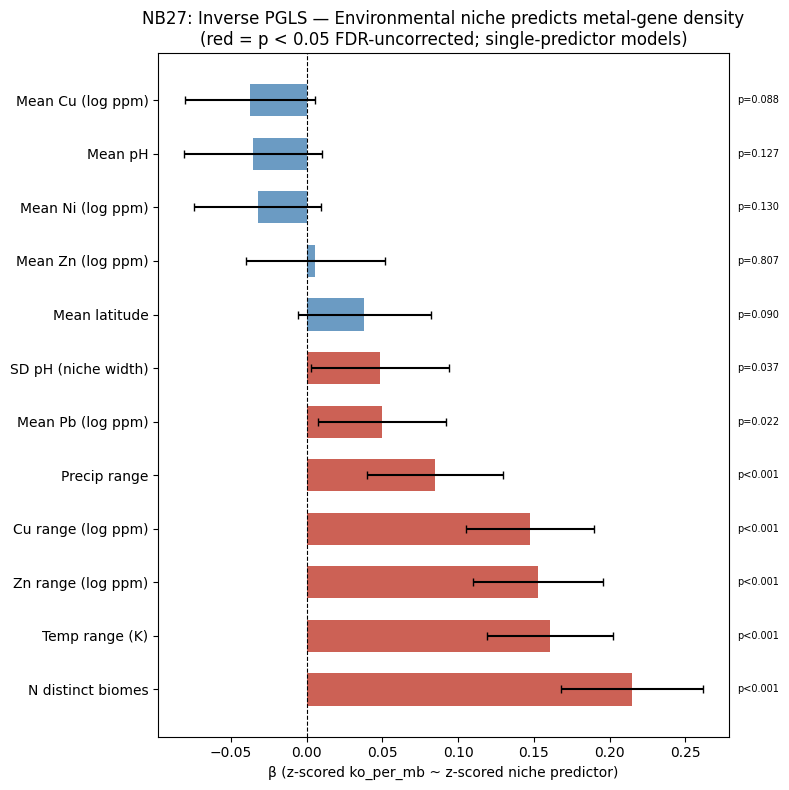

Saved nb27_inverse_pgls_forest.png


In [8]:
# Forest plot: single-predictor betas with 95% CI
LABEL_MAP = {
    'mean_Cu_z':      'Mean Cu (log ppm)',
    'mean_Zn_z':      'Mean Zn (log ppm)',
    'mean_Pb_z':      'Mean Pb (log ppm)',
    'mean_Ni_z':      'Mean Ni (log ppm)',
    'mean_pH_z':      'Mean pH',
    'sd_pH_z':        'SD pH (niche width)',
    'Cu_range_z':     'Cu range (log ppm)',
    'Zn_range_z':     'Zn range (log ppm)',
    'temp_range_z':   'Temp range (K)',
    'precip_range_z': 'Precip range',
    'mean_lat_z':     'Mean latitude',
    'n_biomes_z':     'N distinct biomes',
}

plot_df = results_df.copy()
plot_df['ci95'] = 1.96 * plot_df['SE']
plot_df['label_nice'] = plot_df['label'].map(LABEL_MAP).fillna(plot_df['label'])
plot_df = plot_df.sort_values('beta', ascending=False)

fig, ax = plt.subplots(figsize=(8, 0.5 * len(plot_df) + 2))
y = range(len(plot_df))

colors = ['#c0392b' if row.p_value < 0.05 else 'steelblue' for _, row in plot_df.iterrows()]
ax.barh(list(y), plot_df['beta'].values, xerr=plot_df['ci95'].values,
        color=colors, alpha=0.8, ecolor='black', capsize=3, height=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(list(y))
ax.set_yticklabels(plot_df['label_nice'].values)
ax.set_xlabel('β (z-scored ko_per_mb ~ z-scored niche predictor)')
ax.set_title('NB27: Inverse PGLS — Environmental niche predicts metal-gene density\n'
             '(red = p < 0.05 FDR-uncorrected; single-predictor models)')

# Annotate p-values
for i, (_, row) in enumerate(plot_df.iterrows()):
    p_str = f'p={row.p_value:.3f}' if row.p_value >= 0.001 else 'p<0.001'
    ax.text(ax.get_xlim()[1] * 1.02, i, p_str, va='center', fontsize=7)

plt.tight_layout()
plt.savefig(FIGS / 'nb27_inverse_pgls_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved nb27_inverse_pgls_forest.png')

In [9]:
# Print summary for REPORT.md
sig_pos = results_df[(results_df['p_value'] < 0.05) & (results_df['beta'] > 0)]
sig_neg = results_df[(results_df['p_value'] < 0.05) & (results_df['beta'] < 0)]

print('='*70)
print('INVERSE PGLS SUMMARY')
print('='*70)
print(f'\nPositive and significant (p<0.05) predictors of ko_per_mb_primary:')
for _, r in sig_pos.sort_values('p_value').iterrows():
    print(f'  {r["label"]}: beta={r["beta"]:.4f} (SE={r["SE"]:.4f}, p={r["p_value"]:.4f}, n={r["n"]})')

print(f'\nNegative and significant (p<0.05) predictors:')
for _, r in sig_neg.sort_values('p_value').iterrows():
    print(f'  {r["label"]}: beta={r["beta"]:.4f} (SE={r["SE"]:.4f}, p={r["p_value"]:.4f}, n={r["n"]})')

print(f'\nNon-significant predictors (p>=0.05):')
for _, r in results_df[results_df['p_value'] >= 0.05].sort_values('p_value').iterrows():
    print(f'  {r["label"]}: beta={r["beta"]:.4f} (p={r["p_value"]:.4f})')

if multi_res is not None:
    print(f'\nMulti-predictor PGLS: n={multi_res["n"]}, R²={multi_res["r2"]:.4f}, lambda={multi_res["lambda_est"]:.3f}')

print('='*70)
print('[EXPLORATORY: not pre-registered. Positive results warrant confirmatory pre-registration.]')

INVERSE PGLS SUMMARY

Positive and significant (p<0.05) predictors of ko_per_mb_primary:
  n_biomes_z: beta=0.2147 (SE=0.0239, p=0.0000, n=1475)
  temp_range_z: beta=0.1606 (SE=0.0211, p=0.0000, n=1475)
  Zn_range_z: beta=0.1526 (SE=0.0218, p=0.0000, n=1475)
  Cu_range_z: beta=0.1474 (SE=0.0216, p=0.0000, n=1466)
  precip_range_z: beta=0.0847 (SE=0.0229, p=0.0002, n=1475)
  mean_Pb_z: beta=0.0497 (SE=0.0217, p=0.0220, n=1470)
  sd_pH_z: beta=0.0485 (SE=0.0232, p=0.0372, n=1468)

Negative and significant (p<0.05) predictors:

Non-significant predictors (p>=0.05):
  mean_Cu_z: beta=-0.0374 (p=0.0877)
  mean_lat_z: beta=0.0382 (p=0.0901)
  mean_pH_z: beta=-0.0354 (p=0.1268)
  mean_Ni_z: beta=-0.0324 (p=0.1296)
  mean_Zn_z: beta=0.0057 (p=0.8071)

Multi-predictor PGLS: n=1460, R²=0.0628, lambda=0.900
[EXPLORATORY: not pre-registered. Positive results warrant confirmatory pre-registration.]
